# A/B test analysis for the new algorithm of post recommendation

## Setting up the working environment

Downloading the necessary packages:

In [1]:
import pandas as pd
import numpy as np
import pandahouse as ph
import swifter
import hashlib
import scipy as sp
from scipy import stats
from statsmodels.stats.weightstats import ztest
import seaborn as sns
import matplotlib.pyplot as plt

Setting up the connection to the database:

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

connection = {
    'host': os.getenv('CLICKHOUSE_HOST'),
    'database': os.getenv('CLICKHOUSE_DATABASE'),
    'user': os.getenv('CLICKHOUSE_USER'),
    'password': os.getenv('CLICKHOUSE_PASSWORD')
}


## А/A test


Before conducting the experiment, I will analyze the data and the splitting system to ensure that the data is split evenly and correctly into groups. To do this, I will run an A/A test.

Here, I am running a database query that retrieves data for the two groups (1 - control, 2 - test) for the period from November 14, 2025, to November 20, 2025, inclusive (the week before the planned experiment).

In [3]:
q_AA = """
SELECT 
    user_id,
    exp_group,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2025-11-14' and '2025-11-20'
    and exp_group in (1, 2)
GROUP BY exp_group, user_id
""".format(db=connection['database'])

df_AA = ph.read_clickhouse(q_AA, connection=connection)
df_AA.groupby('exp_group').count().reset_index()

,exp_group,user_id,likes,views,ctr
0,1,8491,8491,8491,8491
1,2,8362,8362,8362,8362


Overall, we can see that the group split is even: in both groups, we have approximately the same number of users.

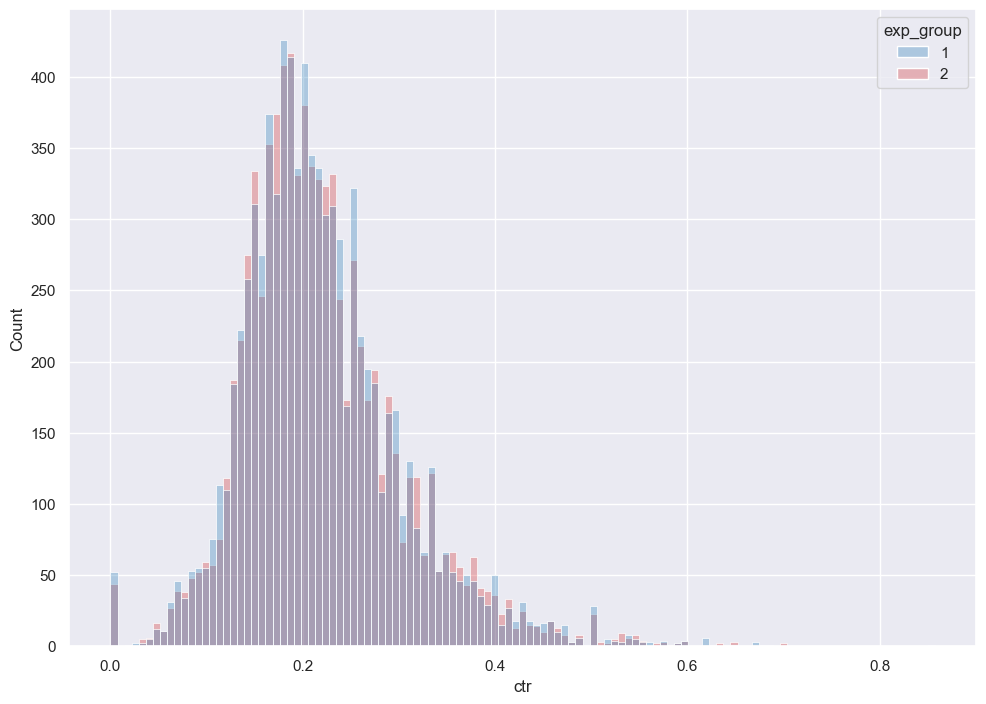

In [4]:
sns.set(rc = {'figure.figsize':(11.7,8.27)}) # to set the scale of the graph to make it a bit larger

groups = sns.histplot(data = df_AA,
                      x = 'ctr',
                      hue = 'exp_group',
                      palette = ['tab:blue', 'tab:red'],
                      alpha = 0.3,
                      kde = False)

Judging by the CTR distribution plot, our primary metric doesn't differ between the groups before the experiment. Let's verify this with a statistical test, but first I will verify the assumption of equal variances between the groups (Levine's test):

In [5]:
statistic, p_value = stats.levene(df_AA[df_AA.exp_group == 1].ctr, df_AA[df_AA.exp_group == 2].ctr)
print(f"Levene's test statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Levene's test statistic: 0.0314
P-value: 0.8593


The test results show that the assumption of equal variances is not violated, so let's look at the t-test with the condition of equal variances.

In [6]:
ttest_result_AA = stats.ttest_ind(df_AA[df_AA.exp_group == 1].ctr,
                df_AA[df_AA.exp_group == 2].ctr,
                equal_var = True,
               alternative = 'two-sided')

print(f"(statistic={ttest_result_AA.statistic:.2f}, pvalue={ttest_result_AA.pvalue:.2f}, df={ttest_result_AA.df:.2f})")


(statistic=-0.57, pvalue=0.57, df=16851.00)


The t-test results show that there is no significant difference between the groups before the experiment (p-value = 0.57). I further confirm this using the Mann-Whitney test:

In [7]:
mann_result_AA = stats.mannwhitneyu(df_AA[df_AA.exp_group == 1].ctr,
                   df_AA[df_AA.exp_group == 2].ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_AA.statistic:.2f}, pvalue={mann_result_AA.pvalue:.2f})")

(statistic=35397948.50, pvalue=0.74)


The Mann-Whitney test also shows no significant differences between the distributions of our control groups.

That is, **before** the experiment, no splitting errors or observed differences between groups unrelated to the experiment were detected. Therefore, we can conduct the experiment and analyze the results.

## A/B test

Now I write a query to the database, in which I extract data for groups 1 (control) and 2 (test) for the dates of the experiment:

In [8]:
q_AB = """
SELECT 
    user_id,
    exp_group,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (1, 2)
GROUP BY exp_group, user_id
""".format(db=connection['database'])

Checking the number of observations in each group:

In [9]:
df_AB = ph.read_clickhouse(q_AB, connection = connection)

df_AB.groupby('exp_group').count().reset_index()

,exp_group,user_id,likes,views,ctr
0,1,10020,10020,10020,10020
1,2,9877,9877,9877,9877


The number of observations across groups is approximately equal. Let's move on to analyzing the experimental results.

### A/B test analysis

Now let's analyze our experiment results.
As a reminder:
* exp_group = 1 - "old algorithm" (control group)
* exp_group = 2 - "New recommendation algorithm: posts similar to the liked posts" (test group)

Checking the distribution of the metric:

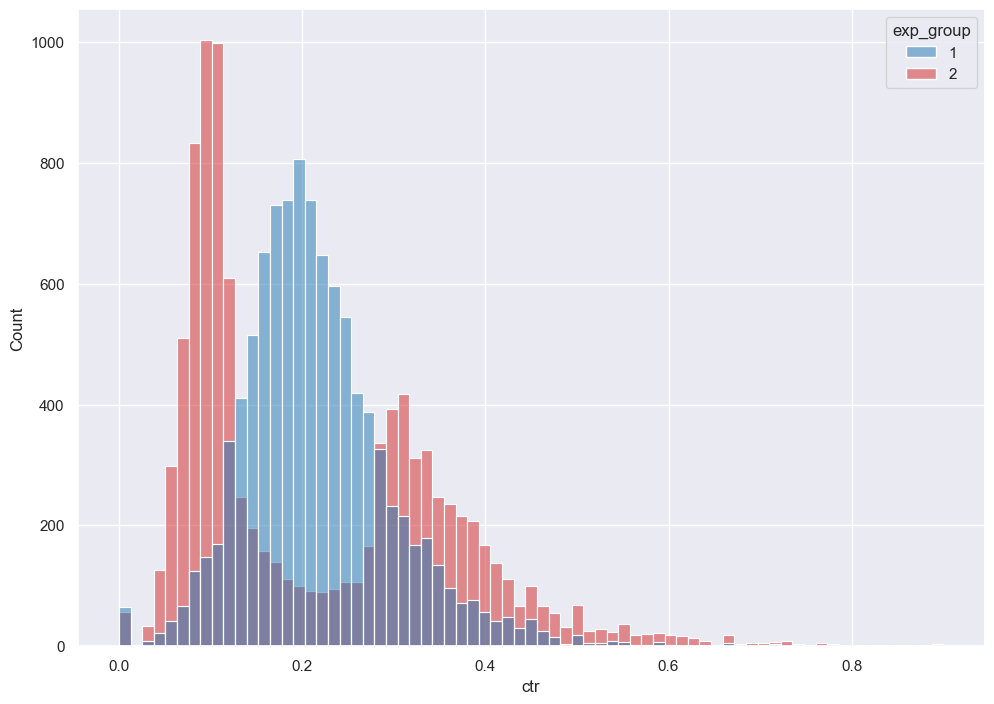

In [10]:
group_distr = sns.histplot(data = df_AB,
                      x = 'ctr',
                      hue = 'exp_group',
                      palette = ['tab:blue', 'tab:red'],
                      alpha = 0.5,
                      kde = False)

The graph shows that the CTR in the test group (2) has a bimodal distribution, while the CTR in the control group (1) is close to normal.

That is, among users in the test group, there are both those who actively liked the posts they viewed and those who rarely did so.

What could be the reason for these results?

1) This may have been influenced by technical glitches during the A/B test (due to which some users in the test group were unable to like posts);

2) Perhaps, our test group sample may contain two user segments that differ significantly in the parameters important for the A/B test that were not accounted for;

3) There may be an unaccounted external factor that could have influenced the user segments within the test group.

In any case, using a parametric t-test with such a distribution is problematic. Therefore, let's look at the Mann-Whitney test first.

### Mann-Whitney U test

In [11]:
mann_result_AB = stats.mannwhitneyu(df_AB[df_AB.exp_group == 1].ctr,
                   df_AB[df_AB.exp_group == 2].ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_AB.statistic:.2f}, pvalue={mann_result_AB.pvalue:.4f})")

(statistic=55189913.00, pvalue=0.0000)


**Interpretation:** the Mann-Whitney test shows a significant difference in the CTR distributions between the control and test groups (p-value = 0.000). However, given the bimodal distribution in the test group, it makes sense to conduct the analysis using additional methods.

### T-test for a smoothed CTR

It may be useful to look at the smoothed CTR instead of the per-user CTR, as we may have users with a small number of views, and their CTR will be noisy. That is, the fewer views a user has, the more difficult it is to meaningfully evaluate their CTR, regardless of likes (for example, 3 likes out of 3 views = 100% CTR, but this CTR is clearly not equivalent to the same CTR with 30 likes/30 views, or, even more so, 300 likes/300 views).

Therefore, we can conduct tests based on the smoothed CTR metric (Laplace smoothing), calculated using the formula: 
$$smoothedCTR_{u} =  {{likes_u + \alpha * globalCTR} \over {views_u + \alpha}} $$

In [12]:
# creating a function to calculate the smoothed CTR:
def get_smoothed_ctr(user_likes, user_views, global_ctr, alpha):
    
    smoothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    
    return smoothed_ctr

In [13]:
# calculating global CTR for the control group:    
global_ctr_1 = df_AB[df_AB.exp_group == 1].likes.sum()/df_AB[df_AB.exp_group == 1].views.sum()

# calculating global CTR for the test group:
global_ctr_2 = df_AB[df_AB.exp_group == 2].likes.sum()/df_AB[df_AB.exp_group == 2].views.sum()


In [14]:
# creating a dataframe for the control group (including the per-user CTR and the smoothed one)

group1 = df_AB[df_AB.exp_group == 1].copy()

group1['smoothed_ctr'] = df_AB.apply(lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis = 1)

In [15]:
# checking the dataframe
group1.head()

,user_id,exp_group,likes,views,ctr,smoothed_ctr
0,109963,1,3,15,0.200000,0.202401
1,26117,1,32,141,0.226950,0.226356
2,138232,1,18,73,0.246575,0.244205
3,26295,1,39,141,0.276596,0.274302
4,18392,1,7,32,0.218750,0.217514


In [16]:
# creating the dataframe with the two CTR types for the test group:

group2 = df_AB[df_AB.exp_group == 2].copy()

group2['smoothed_ctr'] = df_AB.apply(lambda x: get_smoothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis = 1)

In [17]:
# checking the dataframe
group2.head()

,user_id,exp_group,likes,views,ctr,smoothed_ctr
5,131473,2,9,108,0.083333,0.088507
6,23985,2,7,87,0.080460,0.086970
7,24523,2,11,101,0.108911,0.113219
8,32420,2,13,44,0.295455,0.285740
9,24239,2,40,90,0.444444,0.431592


Now let's look at the distribution of smoothed CTR in both groups:

Text(0.5, 1.0, 'Тестовая')

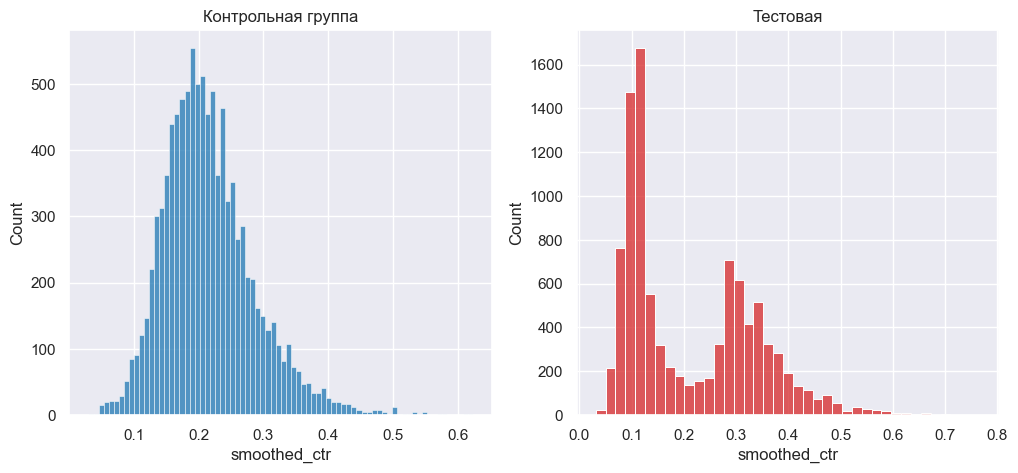

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(group1.smoothed_ctr, color = 'tab:blue', kde = False, ax=axes[0])
axes[0].set_title('Контрольная группа')
sns.histplot(group2.smoothed_ctr, color = 'tab:red', kde = False, ax=axes[1])
axes[1].set_title('Тестовая')



Again, the bimodal distribution is not suitable for implementing a parametric test, so we will rely on the nonparametric Mann-Whitney test:

In [19]:
mann_result_smooth = stats.mannwhitneyu(group1.smoothed_ctr,
                   group2.smoothed_ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_smooth.statistic:.2f}, pvalue={mann_result_smooth.pvalue:.4f})")

(statistic=55528353.00, pvalue=0.0000)


**Interpretation:** the Mann-Whitney test results show significant differences in ranks between the test and control groups. Therefore, based on the results of this test, we can also conclude that the CTR with the new recommendation algorithm is significantly different from the CTR with the old one. Moreover, given the positive value of the statistic (55528353.0), the CTR in the control group is higher than in the test group.

### Poisson bootstrap

Now, I will compare the samples using the Poisson bootstrap method. To do this, I will first calculate likes and views within each group. Next, I will calculate the global CTR for each A/B test group using the following formulas:

* for the **control** group:
$$ globalCTR_A = {sum(likes_A * weights_1)\over sum(views_A * weights_1)}$$

* for the **test** group:
$$ globalCTR_B = {sum(likes_B * weights_2)\over sum(views_B * weights_2)}$$

Finally, I will compare global CTRs and look at the differences between them.  

Creating a function to calculate the global CTR for both groups:

In [20]:
def bootstrap(likes_control, views_control, likes_test, views_test, n_bootstrap):
    
    weights_control = stats.poisson(1).rvs((n_bootstrap, len(likes_control))).astype(np.int64)
    
    weights_test = stats.poisson(1).rvs((n_bootstrap, len(likes_test))).astype(np.int64)
    
    globalCTR_control = (likes_control * weights_control).sum(axis = 1) / (views_control * weights_control).sum(axis = 1)
    
    globalCTR_test = (likes_test * weights_test).sum(axis = 1)/(views_test * weights_test).sum(axis = 1)
    
    return globalCTR_control, globalCTR_test

Creating the lists of values ​​for the number of likes and views for each of the A/B test groups:

In [21]:
likes_a = df_AB[df_AB.exp_group == 1].likes.to_numpy()
views_a = df_AB[df_AB.exp_group == 1].views.to_numpy()

likes_b = df_AB[df_AB.exp_group == 2].likes.to_numpy()
views_b = df_AB[df_AB.exp_group == 2].views.to_numpy()

Calculating the CTR with 2000 simulations:

In [22]:
ctr_a, ctr_b = bootstrap(likes_a, views_a, likes_b, views_b, n_bootstrap = 2000)

<Axes: ylabel='Count'>

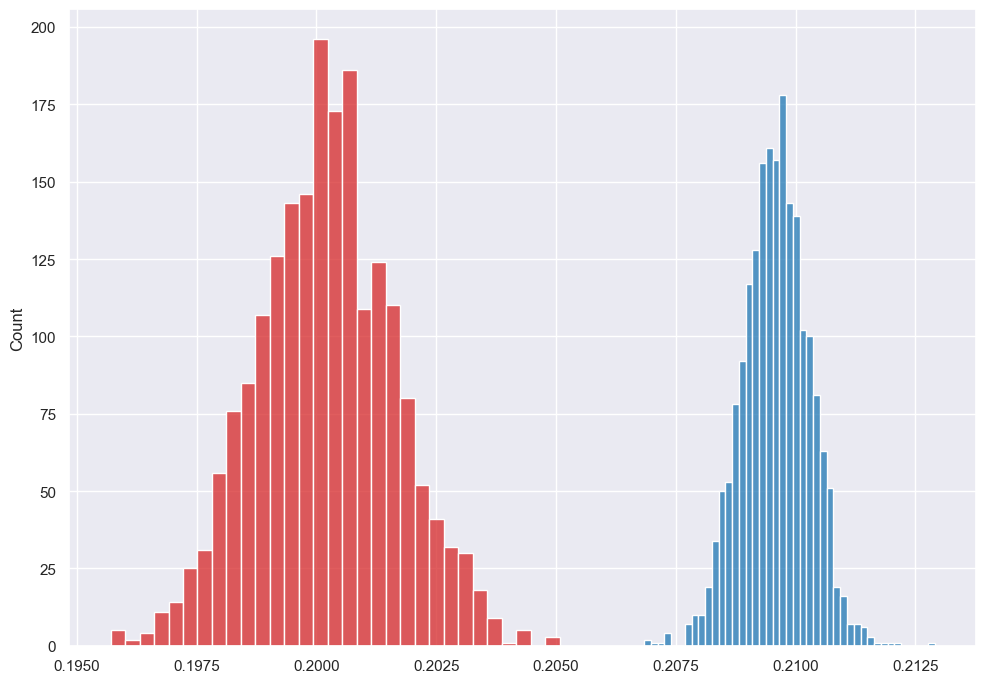

In [23]:
sns.histplot(ctr_a, color = 'tab:blue')
sns.histplot(ctr_b, color = 'tab:red')

<Axes: ylabel='Count'>

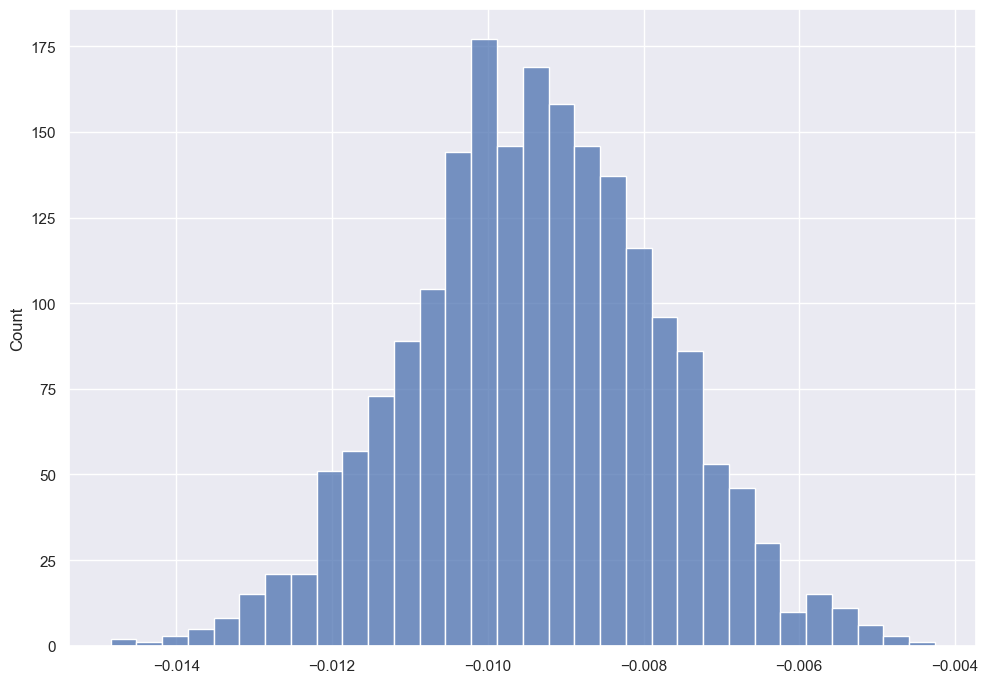

In [24]:
sns.histplot(ctr_b - ctr_a) # checking the distribution of the CTR difference

Overall, the histogram of CTR distributions and the difference in CTR between the control and test groups shows a significant difference (the CTR distribution graphs across groups do not intersect, and the difference distribution histogram does not cross 0). Moreover, the CTR in the test group (ctr_b) is lower than the CTR in the control group (ctr_a), as indicated by the negative values ​​of the difference distribution between the metrics.

This can also be seen in the group average values ​​themselves. The difference in average CTR in the control group is approximately 1% higher than in the test group:

In [25]:
print(f"CTR in the control group: {ctr_a.mean():.4f}\nCTR in the test group: {ctr_b.mean():.4f}")

CTR in the control group: 0.2096
CTR in the test group: 0.2002


Turns out our new algorithm not only significantly impacted user CTR, but even reduced it.

### Bucket transformation

Let's use another A/B test analysis method: bucket transformation. To do this, I will use a hashing 'with salt' to split users into 50 buckets (groups), calculate the average CTR for each bucket, and compare them for the control and test groups.

In [26]:
q_backet = """
SELECT 
    exp_group, 
    bucket,
    sum(likes)/sum(views) as bucket_ctr
FROM (SELECT 
        exp_group,
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM {db}.feed_actions
    WHERE toDate(time) between '2025-11-21' and '2025-11-27'
        and exp_group in (1, 2)
GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
""".format(db=connection['database'])

In [27]:
df_bucket = ph.read_clickhouse(q_backet, connection = connection)
df_bucket.head()

,exp_group,bucket,bucket_ctr
0,1,0,0.200592
1,2,0,0.196510
2,1,1,0.208799
3,2,1,0.210375
4,1,2,0.204632


<Axes: xlabel='bucket_ctr', ylabel='Count'>

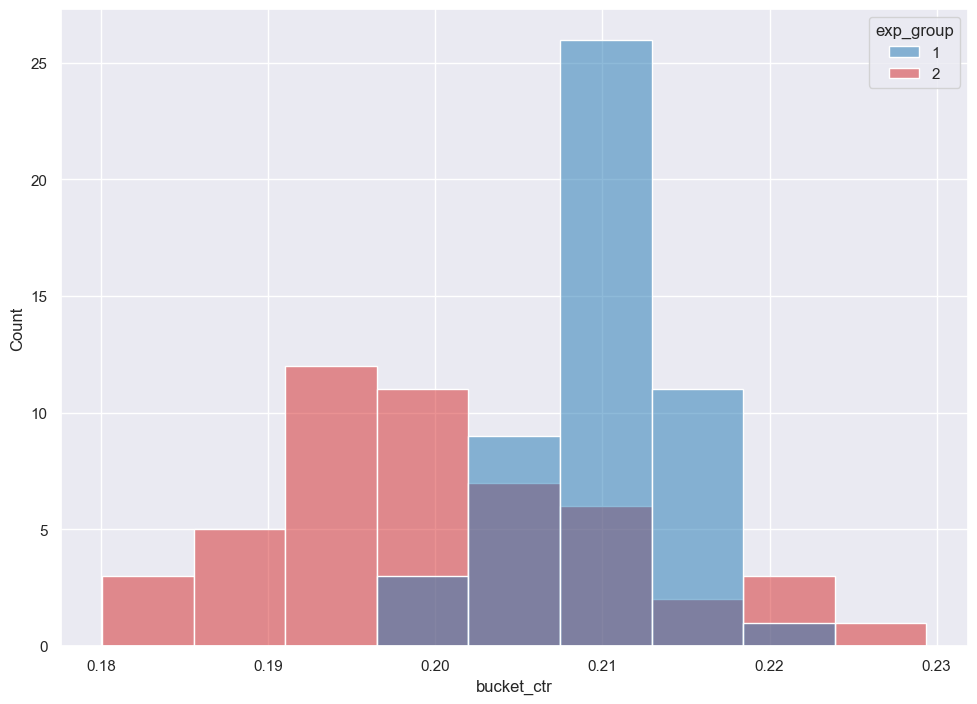

In [28]:
sns.histplot(data = df_bucket,
             x = 'bucket_ctr',
             hue = 'exp_group',
             palette = ['tab:blue', 'tab:red'],
             alpha=0.5,
             kde = False)

The distributions also show differences between the groups, with the CTR in the control group being higher than in the test group, as we also observed with bootstrapping.

These distributions already allow us to calculate a t-test. Therefore, let's compare the results of the t-test and the Mann-Whitney test on bucket samples, after first verifying the assumption of equal variances:

In [29]:
statistic, p_value = stats.levene(df_bucket[df_bucket.exp_group == 1].bucket_ctr,
                df_bucket[df_bucket.exp_group == 2].bucket_ctr,)
print(f"Levene's test statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

Levene's test statistic: 19.5178
P-value: 0.0000


Levine's test shows that the variances across groups are significantly unequal, so we will calculate a t-test with Welch's correction for inequality of variances:

In [30]:
ttest_result_bucket = stats.ttest_ind(df_bucket[df_bucket.exp_group == 1].bucket_ctr,
                df_bucket[df_bucket.exp_group == 2].bucket_ctr,
                equal_var = False,
                alternative = 'two-sided')

print(f"(statistic={ttest_result_bucket.statistic:.2f}, pvalue={ttest_result_bucket.pvalue:.4f}, df={ttest_result_bucket.df:.2f})")


(statistic=5.61, pvalue=0.0000, df=63.83)


In [31]:
# Mann-Whitney U test
mann_result_bucket = stats.mannwhitneyu(df_bucket[df_bucket.exp_group == 1].bucket_ctr,
                   df_bucket[df_bucket.exp_group == 2].bucket_ctr,
                   alternative = 'two-sided')

print(f"(statistic={mann_result_bucket.statistic:.2f}, pvalue={mann_result_bucket.pvalue:.4f})")

(statistic=1997.00, pvalue=0.0000)


**Interpretation:** both tests show a significant difference between the groups (p < 0.01). That is, based on the results of the bucket transformation test, we can conclude that the group of users with the new post recommendation algorithm, on average, has a significantly different CTR from views to likes than users with the old recommendation algorithm.

Let's look at the difference in means:

In [32]:
mean_bucket_ctr_control = df_bucket[df_bucket.exp_group == 1].bucket_ctr.mean()
mean_bucket_ctr_test = df_bucket[df_bucket.exp_group == 2].bucket_ctr.mean()

print(f"Difference in CTR (test vs. control): {mean_bucket_ctr_test - mean_bucket_ctr_control:.4f}")

Difference in CTR (test vs. control): -0.0092


It also turns out that, on average, the CTR of the test group is lower than the CTR in the control group by approximately 1%.

## Recommendations

❌ Based on the analysis results, it's best **not to roll out** the new algorithm to all users.

1) the initial distribution of the target metric in the test group indicates the presence of some significant unaccounted parameter that influenced the outcome of the A/B test. It might be worthwhile to further segment the data to understand whether and what kind of unaccounted variation influenced the results.

2) even without accounting for bimodality in the data, the results of the tests on adjusted distributions using bootstrapping and bucketing indicate a negative effect of the new algorithm: CTR is significantly lower in the test group than in the control group.